# Step-by-Step Visual Test Notebook for `test_coarse_direction_grouping.py`

This notebook mirrors the checks in `tests/test_coarse_direction_grouping.py` and adds visualizations for:
- 24 fine offsets and `G1..G8` grouping
- mean vectors and representative angles (image-coordinate convention)
- fusion behavior (`mean`, `weighted_sum`, `conv1x1`, `attention_gating`)
- canonical 8-direction output ordering

## 0) Environment Setup

- Assumes execution from repository root (`DconnNet`).
- Uses `.venv` kernel.

In [1]:
import importlib
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import autorootcwd
from connect_loss import resolve_connectivity_layout
from model.coarse_direction_grouping import (
    CoarseDirectionReducer,
    FUSION_TYPES,
    build_group_index_map_from_offsets,
    compute_group_mean_vectors,
    compute_representative_angles,
    get_canonical8_to_group_index,
    summarize_coarse_direction_metadata,
)
from model.resnet import resnet34 as build_resnet34

repo_root = Path.cwd()
assert (repo_root / "connect_loss.py").exists(), "Run this notebook at DconnNet repo root."
print("repo_root =", repo_root)
print("torch version =", torch.__version__)

repo_root = /home/suhohan/DconnNet
torch version = 2.11.0+cu128


## 1) Load Reference Constants from `tests/test_coarse_direction_grouping.py`

In [2]:
test_file = repo_root / "tests" / "test_coarse_direction_grouping.py"
spec = importlib.util.spec_from_file_location("coarse_group_test_ref", test_file)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

EXPECTED_GROUP_INDEX_MAP = module.EXPECTED_GROUP_INDEX_MAP
EXPECTED_MEAN_VECTORS = module.EXPECTED_MEAN_VECTORS
EXPECTED_ANGLES = module.EXPECTED_ANGLES

print("Loaded constants from:", test_file)
print("EXPECTED_GROUP_INDEX_MAP =", EXPECTED_GROUP_INDEX_MAP)

Loaded constants from: /home/suhohan/DconnNet/tests/test_coarse_direction_grouping.py
EXPECTED_GROUP_INDEX_MAP = [[3, 16, 14], [5, 12, 11], [6, 10, 9], [7, 8, 13], [4, 15, 17], [2, 19, 20], [1, 21, 22], [0, 23, 18]]


## 2) Verify 24-Channel Layout -> `G1..G8` Group Mapping

In [3]:
offsets_dydx = resolve_connectivity_layout(24)["offsets"]
group_index_map = build_group_index_map_from_offsets(offsets_dydx)

print("Computed group index map:", group_index_map)
assert group_index_map == EXPECTED_GROUP_INDEX_MAP
print("PASS: group index map matches EXPECTED_GROUP_INDEX_MAP")

Computed group index map: [[3, 16, 14], [5, 12, 11], [6, 10, 9], [7, 8, 13], [4, 15, 17], [2, 19, 20], [1, 21, 22], [0, 23, 18]]
PASS: group index map matches EXPECTED_GROUP_INDEX_MAP


In [4]:
# Build a compact table for inspection.
# connect_loss layout stores offsets as (dy, dx), while grouping semantics use (dx, dy).
import pandas as pd
rows = []
for ch, (dy, dx) in enumerate(offsets_dydx):
    group_name = None
    for gi, channels in enumerate(group_index_map):
        if ch in channels:
            group_name = f"G{gi+1}"
            break
    rows.append((ch, dy, dx, dx, dy, group_name))


df_offsets = pd.DataFrame(rows, columns=["channel", "dy", "dx", "dx(view)", "dy(view)", "group"])
df_offsets

,channel,dy,dx,dx(view),dy(view),group
0,0,1,1,1,1,G8
1,1,1,0,0,1,G7
2,2,1,-1,-1,1,G6
3,3,0,1,1,0,G1
4,4,0,-1,-1,0,G5
5,5,-1,1,1,-1,G2
6,6,-1,0,0,-1,G3
7,7,-1,-1,-1,-1,G4
8,8,-2,-2,-2,-2,G4
9,9,-2,-1,-1,-2,G3


### Visualization: 24 fine offsets colored by `G1..G8`

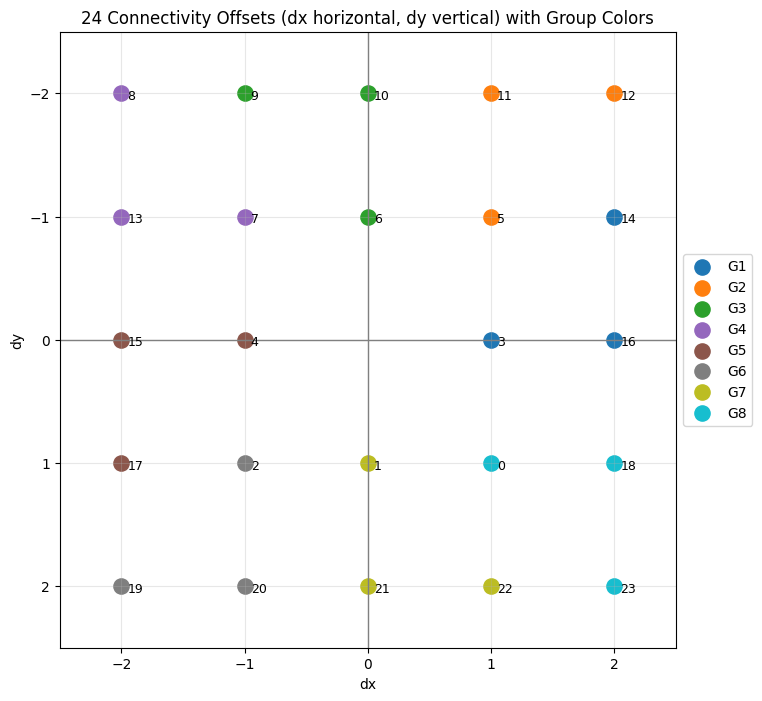

In [5]:
plt.figure(figsize=(8, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for gi, channel_indices in enumerate(group_index_map):
    xs = []
    ys = []
    for ch in channel_indices:
        dy, dx = offsets_dydx[ch]
        xs.append(dx)
        ys.append(dy)
        plt.text(dx + 0.05, dy + 0.05, str(ch), fontsize=9)
    plt.scatter(xs, ys, s=120, color=colors[gi], label=f"G{gi+1}")

plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.gca().set_aspect("equal", adjustable="box")
plt.gca().invert_yaxis()  # image-like y-axis orientation
plt.xlim(-2.5, 2.5)
plt.ylim(2.5, -2.5)
plt.xticks(range(-2, 3))
plt.yticks(range(-2, 3))
plt.title("24 Connectivity Offsets (dx horizontal, dy vertical) with Group Colors")
plt.xlabel("dx")
plt.ylabel("dy")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(alpha=0.3)
plt.show()

## 3) Verify Mean Vectors and Representative Angles

Angle convention (image coordinate):
- `(1, 0) = 0°`
- `(0, -1) = 90°`
- `(-1, 0) = 180°`
- `(0, 1) = 270°`

In [6]:
mean_vectors = compute_group_mean_vectors()
angles = compute_representative_angles()

assert torch.allclose(mean_vectors, EXPECTED_MEAN_VECTORS, atol=1e-6)
assert torch.allclose(angles, EXPECTED_ANGLES, atol=1e-4)
print("PASS: mean vectors and representative angles match expected values")

metadata = summarize_coarse_direction_metadata(offsets_dydx)
pd.DataFrame(metadata)

PASS: mean vectors and representative angles match expected values


,group_name,group_index,offsets_dxdy,mean_vector_dxdy,representative_angle_deg,fine_channel_indices
0,G1,0,"[(1, 0), (2, 0), (2, -1)]","(1.6666666269302368, -0.3333333432674408)",11.309937,"[3, 16, 14]"
1,G2,1,"[(1, -1), (2, -2), (1, -2)]","(1.3333333730697632, -1.6666666269302368)",51.340179,"[5, 12, 11]"
2,G3,2,"[(0, -1), (0, -2), (-1, -2)]","(-0.3333333432674408, -1.6666666269302368)",101.309937,"[6, 10, 9]"
3,G4,3,"[(-1, -1), (-2, -2), (-2, -1)]","(-1.6666666269302368, -1.3333333730697632)",141.340210,"[7, 8, 13]"
4,G5,4,"[(-1, 0), (-2, 0), (-2, 1)]","(-1.6666666269302368, 0.3333333432674408)",191.309921,"[4, 15, 17]"
5,G6,5,"[(-1, 1), (-2, 2), (-1, 2)]","(-1.3333333730697632, 1.6666666269302368)",231.340195,"[2, 19, 20]"
6,G7,6,"[(0, 1), (0, 2), (1, 2)]","(0.3333333432674408, 1.6666666269302368)",281.309937,"[1, 21, 22]"
7,G8,7,"[(1, 1), (2, 2), (2, 1)]","(1.6666666269302368, 1.3333333730697632)",321.340179,"[0, 23, 18]"


### Visualization: Group points + mean vector arrows

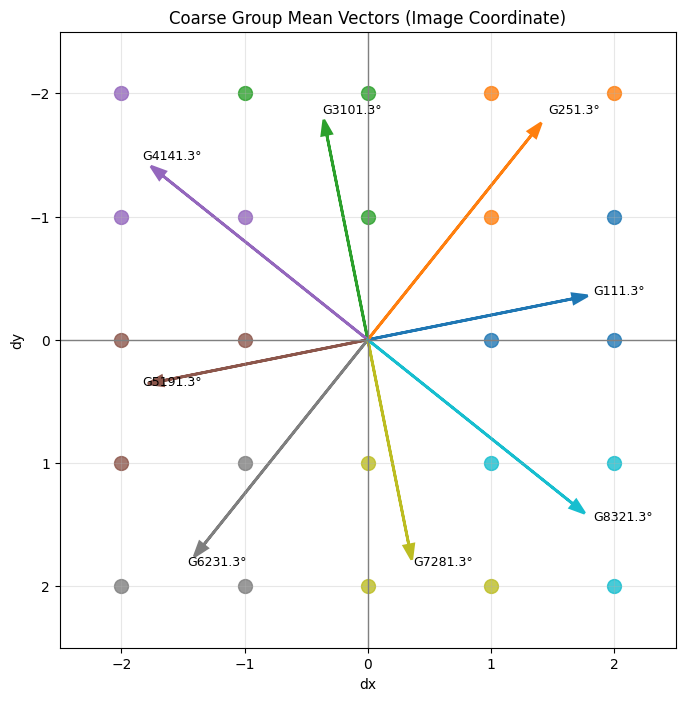

In [7]:
plt.figure(figsize=(8, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for gi, channel_indices in enumerate(group_index_map):
    xs = []
    ys = []
    for ch in channel_indices:
        dy, dx = offsets_dydx[ch]
        xs.append(dx)
        ys.append(dy)
    plt.scatter(xs, ys, s=100, color=colors[gi], alpha=0.8)

    mx = mean_vectors[gi, 0].item()  # dx
    my = mean_vectors[gi, 1].item()  # dy
    plt.arrow(0, 0, mx, my, head_width=0.08, head_length=0.12, color=colors[gi], linewidth=2)
    plt.text(mx * 1.1, my * 1.1, f"G{gi+1}{angles[gi].item():.1f}°", fontsize=9)

plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.gca().set_aspect("equal", adjustable="box")
plt.gca().invert_yaxis()
plt.xlim(-2.5, 2.5)
plt.ylim(2.5, -2.5)
plt.xticks(range(-2, 3))
plt.yticks(range(-2, 3))
plt.title("Coarse Group Mean Vectors (Image Coordinate)")
plt.xlabel("dx")
plt.ylabel("dy")
plt.grid(alpha=0.3)
plt.show()

## 4) Fusion-Block Checks (`24 -> 8`)

In [8]:
torch.manual_seed(0)
x = torch.randn(2, 48, 5, 6)

for fusion_type in FUSION_TYPES:
    reducer = CoarseDirectionReducer(num_classes=2, fusion_type=fusion_type)
    out = reducer(x)
    print(f"{fusion_type:16s} -> shape={tuple(out.shape)}, finite={torch.isfinite(out).all().item()}")
    assert out.shape == (2, 16, 5, 6)
    assert torch.isfinite(out).all()

print("PASS: all fusion types produce valid 24->8 reductions")

mean             -> shape=(2, 16, 5, 6), finite=True
weighted_sum     -> shape=(2, 16, 5, 6), finite=True
conv1x1          -> shape=(2, 16, 5, 6), finite=True
attention_gating -> shape=(2, 16, 5, 6), finite=True
PASS: all fusion types produce valid 24->8 reductions


In [9]:
# Check the intended initialization behavior against mean fusion.
torch.manual_seed(1)
x_vis = torch.randn(1, 24, 16, 16)

mean_reducer = CoarseDirectionReducer(num_classes=1, fusion_type="mean")
mean_out = mean_reducer(x_vis)

outs = {"mean": mean_out}
for fusion_type in ("weighted_sum", "conv1x1", "attention_gating"):
    outs[fusion_type] = CoarseDirectionReducer(num_classes=1, fusion_type=fusion_type)(x_vis)
    assert torch.allclose(outs[fusion_type], mean_out, atol=1e-6, rtol=1e-6)

print("PASS: weighted_sum/conv1x1/attention_gating start as mean-like")

PASS: weighted_sum/conv1x1/attention_gating start as mean-like


### Visualization: One output channel per fusion mode

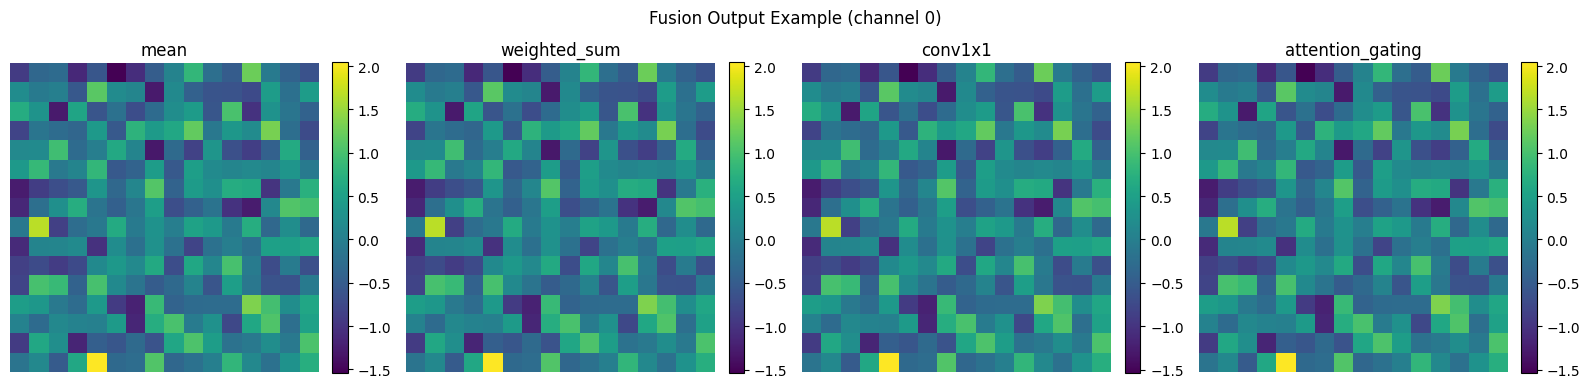

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
mode_order = ["mean", "weighted_sum", "conv1x1", "attention_gating"]

for ax, mode in zip(axes, mode_order):
    im = ax.imshow(outs[mode][0, 0].detach().cpu().numpy(), cmap="viridis")
    ax.set_title(mode)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Fusion Output Example (channel 0)")
plt.tight_layout()
plt.show()

## 5) Canonical 8-Direction Reordering Check

In [11]:
x_order = torch.zeros((1, 24, 1, 1), dtype=torch.float32)
for fine_idx in EXPECTED_GROUP_INDEX_MAP[0]:
    x_order[0, fine_idx, 0, 0] = 1.0

reducer = CoarseDirectionReducer(num_classes=1, fusion_type="mean", output_order="canonical8")
out = reducer(x_order).view(1, 1, 8, 1, 1)

canonical8_to_group = get_canonical8_to_group_index()
print("canonical8_to_group_index:", canonical8_to_group)
print("flattened output:", out.view(-1).tolist())

canonical_idx_for_g1 = 3
assert canonical8_to_group == [7, 6, 5, 0, 4, 1, 2, 3]
assert torch.isclose(out[0, 0, canonical_idx_for_g1, 0, 0], torch.tensor(1.0))
assert torch.count_nonzero(out) == 1
print("PASS: canonical ordering is aligned with existing loss layout")

canonical8_to_group_index: [7, 6, 5, 0, 4, 1, 2, 3]
flattened output: [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
PASS: canonical ordering is aligned with existing loss layout


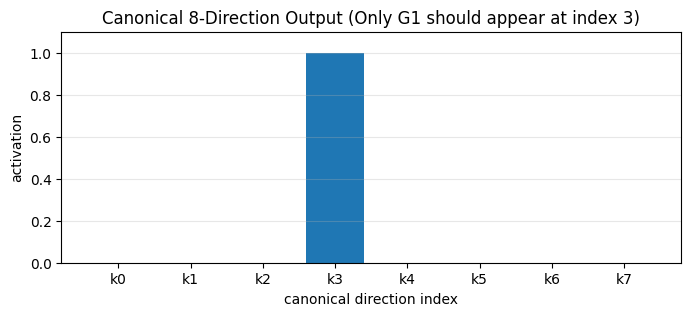

In [12]:
plt.figure(figsize=(8, 3))
vals = out.view(-1).detach().cpu().numpy()
plt.bar(np.arange(8), vals)
plt.xticks(np.arange(8), [f"k{i}" for i in range(8)])
plt.ylim(0, 1.1)
plt.title("Canonical 8-Direction Output (Only G1 should appear at index 3)")
plt.xlabel("canonical direction index")
plt.ylabel("activation")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 6) Grouped DconnNet Forward Smoke Test

Monkeypatch `resnet34(pretrained=True)` to avoid downloading weights in notebook runs.

In [13]:
dconnnet_module = importlib.import_module("model.DconnNet")
dconnnet_module.resnet34 = lambda pretrained=True, **kwargs: build_resnet34(pretrained=False, **kwargs)

model = dconnnet_module.DconnNet(
    num_class=1,
    conn_num=8,
    direction_grouping="coarse24to8",
    direction_fusion="weighted_sum",
).eval()

x_model = torch.randn(1, 3, 64, 64)
with torch.no_grad():
    main_out, aux_out = model(x_model)

print("main_out shape:", tuple(main_out.shape))
print("aux_out shape:", tuple(aux_out.shape))
assert main_out.shape == (1, 8, 64, 64)
assert aux_out.shape == (1, 8, 64, 64)
print("PASS: grouped DconnNet returns canonical 8-direction outputs")

main_out shape: (1, 8, 64, 64)
aux_out shape: (1, 8, 64, 64)
PASS: grouped DconnNet returns canonical 8-direction outputs


## 7) Non-8 Final Branch Rejection Check

In [14]:
try:
    _ = dconnnet_module.DconnNet(
        num_class=1,
        conn_num=24,
        direction_grouping="coarse24to8",
    )
except ValueError as exc:
    print("Expected error:", exc)
    assert "requires conn_num=8" in str(exc)
else:
    raise AssertionError("Expected ValueError was not raised")

Expected error: direction_grouping='coarse24to8' requires conn_num=8 for the final branch layout


## 8) PCA Separation Check for 8-Channel Fusion Output

Goal:
- Take fused 8-channel output and test whether channel responses are separable in PCA space.
- Visualize per-pixel embeddings with color = `argmax(channel)`.

In [15]:
# Load a trained model checkpoint and extract 8-channel fusion output for PCA.
# Set these paths before running.
from pathlib import Path
import cv2
import numpy as np
import torch
import importlib

CHECKPOINT_PATH = "output/chase/dist_inverted_8_gjml_sf_l1/models/1/500_model.pth"  # e.g., "output/chase/binary_8_bce_coarse24to8_weighted_sum/models/best_dice_model.pth"
IMAGE_PATH = "data/chase/images/Image_01L.jpg"       # e.g., "/absolute/path/to/sample.png"
RESIZE_HW = (960, 960)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Model config used for the trained checkpoint.
NUM_CLASS = 1
CONN_NUM = 8
DIRECTION_GROUPING = "coarse24to8"   # "none" or "coarse24to8"
DIRECTION_FUSION = "weighted_sum"    # "mean", "weighted_sum", "conv1x1", "attention_gating"
FEATURE_SOURCE = "main_out"          # "main_out" or "aux_out"
CLASS_INDEX = 0                       # used when NUM_CLASS > 1

if CHECKPOINT_PATH is None:
    candidates = sorted(repo_root.glob("output/**/models/*.pth"), key=lambda x: x.stat().st_mtime, reverse=True)
    if len(candidates) == 0:
        raise FileNotFoundError("No checkpoint found automatically. Set CHECKPOINT_PATH explicitly.")
    CHECKPOINT_PATH = str(candidates[0])

ckpt_path = Path(CHECKPOINT_PATH)
if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

if IMAGE_PATH is None:
    raise ValueError("Set IMAGE_PATH to a real sample image path for feature extraction.")

img_path = Path(IMAGE_PATH)
if not img_path.exists():
    raise FileNotFoundError(f"Image not found: {img_path}")

# Avoid pretrained backbone download in notebook runs.
dconnnet_module = importlib.import_module("model.DconnNet")
dconnnet_module.resnet34 = lambda pretrained=True, **kwargs: build_resnet34(pretrained=False, **kwargs)

model = dconnnet_module.DconnNet(
    num_class=NUM_CLASS,
    conn_num=CONN_NUM,
    direction_grouping=DIRECTION_GROUPING,
    direction_fusion=DIRECTION_FUSION,
).to(DEVICE).eval()

checkpoint = torch.load(str(ckpt_path), map_location=DEVICE)
if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
elif isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("checkpoint:", ckpt_path)
print("missing keys:", len(missing), "unexpected keys:", len(unexpected))

# Image -> tensor (B,3,H,W), [0,1]
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise RuntimeError(f"Failed to read image: {img_path}")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (RESIZE_HW[1], RESIZE_HW[0]), interpolation=cv2.INTER_LINEAR)
x_np = img_resized.astype(np.float32) / 255.0
x_t = torch.from_numpy(x_np).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    main_out, aux_out = model(x_t)

feat = main_out if FEATURE_SOURCE == "main_out" else aux_out
if feat.shape[1] % 8 != 0:
    raise ValueError(f"Expected channel size multiple of 8, got {feat.shape}")

if NUM_CLASS == 1:
    out_pca = feat[:, :8]
else:
    ch0 = CLASS_INDEX * CONN_NUM
    ch1 = (CLASS_INDEX + 1) * CONN_NUM
    out_pca = feat[:, ch0:ch1]

print("input image:", img_path)
print("input tensor:", tuple(x_t.shape))
print("main_out:", tuple(main_out.shape), "aux_out:", tuple(aux_out.shape))
print("selected feature:", FEATURE_SOURCE, tuple(out_pca.shape))

# Flatten per-pixel 8D feature vectors: (N, 8)
pixel_feat = out_pca[0].permute(1, 2, 0).reshape(-1, 8).detach().cpu().numpy()
label_argmax = pixel_feat.argmax(axis=1)
print("pixel_feat shape:", pixel_feat.shape)

RuntimeError: Error(s) in loading state_dict for DconnNet:
	size mismatch for cls_pred_conv_2.weight: copying a param with shape torch.Size([8, 32, 1, 1]) from checkpoint, the shape in current model is torch.Size([24, 32, 1, 1]).
	size mismatch for cls_pred_conv_2.bias: copying a param with shape torch.Size([8]) from checkpoint, the shape in current model is torch.Size([24]).
	size mismatch for channel_mapping.0.weight: copying a param with shape torch.Size([8, 512, 3, 3]) from checkpoint, the shape in current model is torch.Size([24, 512, 3, 3]).
	size mismatch for channel_mapping.0.bias: copying a param with shape torch.Size([8]) from checkpoint, the shape in current model is torch.Size([24]).
	size mismatch for channel_mapping.1.weight: copying a param with shape torch.Size([8]) from checkpoint, the shape in current model is torch.Size([24]).
	size mismatch for channel_mapping.1.bias: copying a param with shape torch.Size([8]) from checkpoint, the shape in current model is torch.Siz

In [ ]:
# PCA projection (prefer sklearn, fallback to torch.pca_lowrank).
try:
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, random_state=0)
    z2 = pca.fit_transform(pixel_feat)
    explained = pca.explained_variance_ratio_
    pca_backend = 'sklearn'
except Exception:
    x_t = torch.from_numpy(pixel_feat).float()
    x_center = x_t - x_t.mean(dim=0, keepdim=True)
    U, S, V = torch.pca_lowrank(x_center, q=2)
    z2_t = x_center @ V[:, :2]
    z2 = z2_t.numpy()
    var = (S ** 2)
    explained = (var[:2] / var.sum()).numpy()
    pca_backend = 'torch.pca_lowrank'

print('PCA backend:', pca_backend)
print('Explained variance ratio (PC1, PC2):', explained)

In [ ]:
# Visualization 1: PCA scatter with argmax-channel coloring
plt.figure(figsize=(8, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 8))

# Subsample for speed/clarity
n = z2.shape[0]
step = max(1, n // 12000)
idx = np.arange(0, n, step)

for ch in range(8):
    mask = label_argmax[idx] == ch
    if mask.any():
        plt.scatter(z2[idx][mask, 0], z2[idx][mask, 1], s=6, alpha=0.35, color=colors[ch], label=f'ch{ch}')

plt.title('PCA of 8-Channel Fusion Output (color=argmax channel)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=2, fontsize=8, ncol=2)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Visualization 2: Channel centroids in PCA space + separation score
centroids = []
for ch in range(8):
    pts = z2[label_argmax == ch]
    if len(pts) == 0:
        centroids.append(np.array([np.nan, np.nan]))
    else:
        centroids.append(pts.mean(axis=0))
centroids = np.stack(centroids, axis=0)

# Simple separability proxy:
# between-class centroid distance / within-class spread
pair_dists = []
for i in range(8):
    for j in range(i + 1, 8):
        if np.isfinite(centroids[i]).all() and np.isfinite(centroids[j]).all():
            pair_dists.append(np.linalg.norm(centroids[i] - centroids[j]))
between = float(np.mean(pair_dists)) if pair_dists else float('nan')

within_list = []
for ch in range(8):
    pts = z2[label_argmax == ch]
    if len(pts) > 1 and np.isfinite(centroids[ch]).all():
        within_list.append(np.mean(np.linalg.norm(pts - centroids[ch], axis=1)))
within = float(np.mean(within_list)) if within_list else float('nan')
sep_ratio = between / (within + 1e-8)

plt.figure(figsize=(7, 6))
plt.scatter(centroids[:, 0], centroids[:, 1], s=180, c=colors, edgecolor='black')
for ch in range(8):
    if np.isfinite(centroids[ch]).all():
        plt.text(centroids[ch, 0], centroids[ch, 1], f'  ch{ch}', fontsize=10)
plt.title('PCA Channel Centroids')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.show()

print(f'between-centroid distance (mean): {between:.4f}')
print(f'within-cluster spread (mean):      {within:.4f}')
print(f'separation ratio (between/within): {sep_ratio:.4f}')
print('Interpretation: higher separation ratio => better channel-wise separability in PCA space.')

### Optional: Compare Trained Checkpoints / Fusion Modes

For trained-model PCA comparisons:
- Change `CHECKPOINT_PATH` and rerun section 8.
- Change `DIRECTION_FUSION` (`'mean'`, `'weighted_sum'`, `'conv1x1'`, `'attention_gating'`) to compare separability.
- Keep the same `IMAGE_PATH` for fair comparison.


## Done

If all cells pass, the notebook has functionally replicated and visualized the assertions from `tests/test_coarse_direction_grouping.py`.